<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Final_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final_Results — Held-Out Test Set Evaluation

**⚠️ READ BEFORE RUNNING**

This notebook evaluates all key models on the **held-out test set** (1,500 samples, never seen during training or validation).

**Models evaluated:**
- Baselines: MobileNetV2, MobileNetV3 (seed 74)
- Teachers: VGG_Pretrained (seed 85), ResNet_Pretrained (seed 52)
- KD: `vgg_mv2_ft`, `vgg_mv2_scratch`, `resnet_mv2_ft`, `resnet_mv2_scratch`
- Unstructured pruning: MV2 + MV3 at 10 / 20 / 30%
- Structured pruning: MV3 2% and 3% (only checkpoints that passed NSE gate)

**Figures saved to Drive:**
- `figures/hw_fp32_vs_int8.png` — FP32 vs INT8 latency and memory
- `figures/all_models_accuracy.png` — all-models accuracy bar chart
- `figures/structured_pruning_nse_gate.png` — NSE gate results
- `figures/final_accuracy_chart.png` — accuracy vs pruning sparsity
- `figures/<model>_cm.png` — confusion matrix per key model

**STM32 on-device results** are loaded from `quantz_records.json` and shown alongside val/test accuracy.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place utils/ at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ──────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

from utils.dataset import prepare_dataset, get_test_loader
from utils.models  import (
    VWW_MobileNetV2, VWW_MobileNetV3,
    VGG_Pretrained, ResNet_Pretrained,
)
from utils.train import setup_device

device = setup_device(seed=41)
CKPT   = Path("/content/drive/My Drive/stm32-thesis/checkpoints")
QUANTZ_RECORDS_JSON = str(CKPT / "quantz_records.json")
FIG_DIR = Path("/content/drive/My Drive/stm32-thesis/outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint dir : {CKPT}")
print(f"Figures dir    : {FIG_DIR}")
print(f"Dir exists     : {CKPT.exists()}")

Device: cuda
Checkpoint dir : /content/drive/My Drive/stm32-thesis/checkpoints
Figures dir    : /content/drive/My Drive/stm32-thesis/outputs/figures
Dir exists     : True


In [3]:
# ── Test set ─────────────────────────────────────────────────────────
prepare_dataset()
test_loader = get_test_loader(batch_size=64)
print("✅ Test loader ready  (1,500 samples — held-out)")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Test: 1500 samples  ⚠️  Use only for final evaluation
✅ Test loader ready  (1,500 samples — held-out)


In [4]:
# ── Evaluation helpers ───────────────────────────────────────────────

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return correct / total, all_preds, all_labels


def load_and_eval(model_cls, ckpt_name, label=None):
    ckpt = CKPT / ckpt_name
    if not ckpt.exists():
        print(f"  ❌  {ckpt_name}  — NOT FOUND")
        return None, None, None
    model = model_cls().to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    acc, preds, labels = evaluate_model(model, test_loader)
    name = label or ckpt_name
    print(f"  ✅  {name:<50}  test: {acc*100:.2f}%")
    return acc, preds, labels


def wilson_ci_95(acc_pct, n=1500):
    """Wilson score 95% CI. Returns (lo%, hi%) as floats."""
    p = acc_pct / 100
    z = 1.96
    center = (p + z**2 / (2*n)) / (1 + z**2 / n)
    margin = z * (p*(1-p)/n + z**2/(4*n**2))**0.5 / (1 + z**2/n)
    return round((center - margin)*100, 2), round((center + margin)*100, 2)


print("✅ Helpers ready")

✅ Helpers ready


In [5]:
# ── Load STM32 results from quantz_records.json ─────────────────────
stm32 = {}

if os.path.exists(QUANTZ_RECORDS_JSON):
    with open(QUANTZ_RECORDS_JSON) as f:
        qrecords = json.load(f)
    for r in qrecords:
        stm32[r["name"]] = {
            "fp32_val"   : r.get("fp32_val_acc_%"),
            "stm32_fp32" : r.get("stm32_fp32_acc_%"),
            "stm32_int8" : r.get("stm32_int8_acc_%"),
            "nse"        : r.get("NSE"),
            "source"     : r.get("source"),
        }
    print(f"✅ Loaded STM32 records for {len(stm32)} models")
    for name, v in stm32.items():
        fp32_s = f"{v['stm32_fp32']:.2f}%" if v["stm32_fp32"] else "pending"
        int8_s = f"{v['stm32_int8']:.2f}%" if v["stm32_int8"] else "pending"
        print(f"  {name:<42}  FP32: {fp32_s:>10}  INT8: {int8_s:>10}")
else:
    print(f"⚠️  quantz_records.json not found — STM32 columns will be empty")
    print(f"   Expected at: {QUANTZ_RECORDS_JSON}")

✅ Loaded STM32 records for 18 models
  mobilenetv3_seed_74                         FP32:     79.50%  INT8:     80.00%
  mobilenetv2_unstructured_10pct              FP32:    pending  INT8:     78.50%
  mobilenetv2_unstructured_20pct              FP32:    pending  INT8:     79.50%
  mobilenetv2_unstructured_30pct              FP32:    pending  INT8:     76.00%
  mobilenetv3_unstructured_10pct              FP32:    pending  INT8:     80.50%
  mobilenetv3_unstructured_20pct              FP32:    pending  INT8:     81.00%
  mobilenetv3_unstructured_30pct              FP32:    pending  INT8:     83.00%
  mobilenetv3_structured_2pct                 FP32:    pending  INT8:     83.00%
  mobilenetv3_structured_3pct                 FP32:    pending  INT8:     84.50%
  vgg_mv2_ft                                  FP32:    pending  INT8:     80.00%
  vgg_mv2_scratch                             FP32:    pending  INT8:     79.00%
  vgg_mv3_ft                                  FP32:    pending  INT8:   

In [6]:
# ── Evaluate all models on held-out test set ─────────────────────────
results = {}

# ── Baselines ────────────────────────────────────────────────────────
print("── Baselines ──")
acc, preds, labels = load_and_eval(VWW_MobileNetV2, "mobilenetv2_seed_74.pth", "MobileNetV2 baseline")
results["MobileNetV2 baseline"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "mobilenetv2_seed_74"}

acc, preds, labels = load_and_eval(VWW_MobileNetV3, "mobilenetv3_seed_74.pth", "MobileNetV3 baseline")
results["MobileNetV3 baseline"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "mobilenetv3_seed_74"}

# ── Teachers ─────────────────────────────────────────────────────────
print("\n── Teachers ──")
acc, preds, labels = load_and_eval(VGG_Pretrained, "vgg_pretrained_seed_85.pth", "VGG Pretrained (teacher)")
results["VGG Pretrained (teacher)"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": None}

acc, preds, labels = load_and_eval(ResNet_Pretrained, "resnet_pretrained_seed_52.pth", "ResNet Pretrained (teacher)")
results["ResNet Pretrained (teacher)"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": None}

# ── Knowledge Distillation ────────────────────────────────────────────
print("\n── Knowledge Distillation ──")
acc, preds, labels = load_and_eval(VWW_MobileNetV2, "vgg_mv2_ft.pth", "MobileNetV2 KD VGG-FT")
results["MobileNetV2 KD VGG-FT"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "vgg_mv2_ft"}

acc, preds, labels = load_and_eval(VWW_MobileNetV2, "vgg_mv2_scratch.pth", "MobileNetV2 KD VGG-scratch")
results["MobileNetV2 KD VGG-scratch"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "vgg_mv2_scratch"}

acc, preds, labels = load_and_eval(VWW_MobileNetV2, "resnet_mv2_ft.pth", "MobileNetV2 KD ResNet-FT")
results["MobileNetV2 KD ResNet-FT"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "resnet_mv2_ft"}

acc, preds, labels = load_and_eval(VWW_MobileNetV2, "resnet_mv2_scratch.pth", "MobileNetV2 KD ResNet-scratch")
results["MobileNetV2 KD ResNet-scratch"] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": "resnet_mv2_scratch"}

# ── Unstructured pruning ──────────────────────────────────────────────
print("\n── Unstructured Pruning ──")
for arch, cls in [("mobilenetv2", VWW_MobileNetV2), ("mobilenetv3", VWW_MobileNetV3)]:
    for pct in [10, 20, 30]:
        ckpt_name = f"{arch}_unstructured_{pct}pct.pth"
        arch_label = "MobileNetV2" if arch == "mobilenetv2" else "MobileNetV3"
        label     = f"{arch_label} unstructured {pct}%"
        stm32_key = f"{arch}_unstructured_{pct}pct"
        acc, preds, labels = load_and_eval(cls, ckpt_name, label)
        results[label] = {"acc": acc, "preds": preds, "labels": labels, "stm32_key": stm32_key}

# ── Structured pruning — V3 2% and 3% only ───────────────────────────
print("\n── Structured Pruning (NSE-passing checkpoints only) ──")
for pct_str, stm32_key in [("2pct", "mobilenetv3_structured_2pct"), ("3pct", "mobilenetv3_structured_3pct")]:
    ckpt  = f"mobilenetv3_structured_{pct_str}.pth"
    label = f"MobileNetV3 structured {pct_str[:-3]}%"
    acc, preds, lbls = load_and_eval(VWW_MobileNetV3, ckpt, label)
    if acc is not None:
        results[label] = {"acc": acc, "preds": preds, "labels": lbls, "stm32_key": stm32_key}

n_ok = sum(1 for r in results.values() if r["acc"] is not None)
print(f"\n✅ Evaluated {n_ok}/{len(results)} models successfully")

── Baselines ──
  ✅  MobileNetV2 baseline                                test: 79.47%
  ✅  MobileNetV3 baseline                                test: 79.13%

── Teachers ──
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:04<00:00, 122MB/s]


  ✅  VGG Pretrained (teacher)                            test: 90.60%
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


  ✅  ResNet Pretrained (teacher)                         test: 89.73%

── Knowledge Distillation ──
  ✅  MobileNetV2 KD VGG-FT                               test: 81.00%
  ✅  MobileNetV2 KD VGG-scratch                          test: 80.40%
  ✅  MobileNetV2 KD ResNet-FT                            test: 80.67%
  ✅  MobileNetV2 KD ResNet-scratch                       test: 81.33%

── Unstructured Pruning ──
  ✅  MobileNetV2 unstructured 10%                        test: 80.40%
  ✅  MobileNetV2 unstructured 20%                        test: 79.73%
  ✅  MobileNetV2 unstructured 30%                        test: 78.47%
  ✅  MobileNetV3 unstructured 10%                        test: 79.13%
  ✅  MobileNetV3 unstructured 20%                        test: 79.07%
  ✅  MobileNetV3 unstructured 30%                        test: 79.07%

── Structured Pruning (NSE-passing checkpoints only) ──
  ✅  MobileNetV3 structured 2%                           test: 79.47%
  ✅  MobileNetV3 structured 3%               

In [7]:
# ── Final results table ──────────────────────────────────────────────
VAL_ACCS = {
    "MobileNetV2 baseline"          : 78.40,
    "MobileNetV3 baseline"          : 79.13,
    "VGG Pretrained (teacher)"      : 89.07,
    "ResNet Pretrained (teacher)"   : 87.93,
    "MobileNetV2 KD VGG-FT"        : 80.07,
    "MobileNetV2 KD VGG-scratch"    : 79.53,
    "MobileNetV2 KD ResNet-FT"      : 79.47,
    "MobileNetV2 KD ResNet-scratch" : 79.53,
    "MobileNetV2 unstructured 10%"  : 78.93,
    "MobileNetV2 unstructured 20%"  : 78.53,
    "MobileNetV2 unstructured 30%"  : 78.27,
    "MobileNetV3 unstructured 10%"  : 78.67,
    "MobileNetV3 unstructured 20%"  : 78.27,
    "MobileNetV3 unstructured 30%"  : 78.47,
    "MobileNetV3 structured 2%"     : 78.87,
    "MobileNetV3 structured 3%"     : 78.73,
}

rows = []
for name, r in results.items():
    if r["acc"] is None:
        continue
    val      = VAL_ACCS.get(name)
    test_acc = round(r["acc"] * 100, 2)
    delta    = round(test_acc - val, 2) if val else None
    ci_lo, ci_hi = wilson_ci_95(test_acc)
    s32 = stm32.get(r["stm32_key"], {}) if r["stm32_key"] else {}
    rows.append({
        "model"        : name,
        "val_acc_%"    : val,
        "test_acc_%"   : test_acc,
        "test_ci_95"   : f"[{ci_lo:.1f}, {ci_hi:.1f}]",
        "test_delta_%" : delta,
        "stm32_fp32_%" : s32.get("stm32_fp32"),
        "stm32_int8_%" : s32.get("stm32_int8"),
        "NSE"          : s32.get("nse"),
    })

df = pd.DataFrame(rows)

W = 120
print("=" * W)
print(f"{'FINAL TEST SET RESULTS  (n=1500, held-out)':^{W}}")
print("=" * W)
print(f"{'Model':<42} {'Val%':>7}  {'Test%':>7}  {'95% CI':>14}  {'Δ(T-V)':>7}  "
      f"{'STM32 FP32':>11}  {'STM32 INT8':>11}  {'NSE':>7}")
print("-" * W)

sections = [
    ("Baselines",
     ["MobileNetV2 baseline", "MobileNetV3 baseline"]),
    ("Teachers (not deployed)",
     ["VGG Pretrained (teacher)", "ResNet Pretrained (teacher)"]),
    ("Knowledge Distillation",
     ["MobileNetV2 KD VGG-FT", "MobileNetV2 KD VGG-scratch",
      "MobileNetV2 KD ResNet-FT", "MobileNetV2 KD ResNet-scratch"]),
    ("Unstructured Pruning",
     ["MobileNetV2 unstructured 10%", "MobileNetV2 unstructured 20%",
      "MobileNetV2 unstructured 30%", "MobileNetV3 unstructured 10%",
      "MobileNetV3 unstructured 20%", "MobileNetV3 unstructured 30%"]),
    ("Structured Pruning  [MV2 all / MV3 5% → failed NSE gate; only below deployed]",
     ["MobileNetV3 structured 2%", "MobileNetV3 structured 3%"]),
]

for section_name, model_names in sections:
    print(f"  {section_name}")
    for name in model_names:
        row = df[df["model"] == name]
        if row.empty:
            continue
        r = row.iloc[0]
        val_s   = f"{r['val_acc_%']:.2f}%"    if r["val_acc_%"]   is not None else "     —"
        test_s  = f"{r['test_acc_%']:.2f}%"
        delta_s = f"{r['test_delta_%']:+.2f}%" if r["test_delta_%"] is not None else "     —"
        ci_s    = r.get("test_ci_95", "             —")
        fp32_s  = f"{r['stm32_fp32_%']:.2f}%"  if r["stm32_fp32_%"] is not None else "   pending"
        int8_s  = f"{r['stm32_int8_%']:.2f}%"  if r["stm32_int8_%"] is not None else "   pending"
        nse_s   = f"{r['NSE']:.4f}"             if r["NSE"]          is not None else "      —"
        print(f"    {name:<40} {val_s:>7}  {test_s:>7}  {ci_s:>14}  {delta_s:>7}  "
              f"{fp32_s:>11}  {int8_s:>11}  {nse_s:>7}")
    print()

print("=" * W)
print("Δ(T-V) = Test − Val  |  95% CI = Wilson score interval  |  n=1500")

                                       FINAL TEST SET RESULTS  (n=1500, held-out)                                       
Model                                         Val%    Test%          95% CI   Δ(T-V)   STM32 FP32   STM32 INT8      NSE
------------------------------------------------------------------------------------------------------------------------
  Baselines
    MobileNetV2 baseline                      78.40%   79.47%    [77.3, 81.4]   +1.07%       76.50%         nan%   0.9777
    MobileNetV3 baseline                      79.13%   79.13%    [77.0, 81.1]   +0.00%       79.50%       80.00%   0.9931

  Teachers (not deployed)
    VGG Pretrained (teacher)                  89.07%   90.60%    [89.0, 92.0]   +1.53%         nan%         nan%      nan
    ResNet Pretrained (teacher)               87.93%   89.73%    [88.1, 91.2]   +1.80%         nan%         nan%      nan

  Knowledge Distillation
    MobileNetV2 KD VGG-FT                     80.07%   81.00%    [78.9, 82.9]   +0.93

In [8]:
# ── Per-class breakdown for key models ──────────────────────────────
key_models = [
    "MobileNetV2 baseline",
    "MobileNetV3 baseline",
    "MobileNetV2 KD VGG-FT",
    "MobileNetV2 KD VGG-scratch",
    "MobileNetV2 KD ResNet-FT",
    "MobileNetV2 KD ResNet-scratch",
    "MobileNetV2 unstructured 10%",
    "MobileNetV2 unstructured 20%",
    "MobileNetV2 unstructured 30%",
    "MobileNetV3 unstructured 10%",
    "MobileNetV3 unstructured 20%",
    "MobileNetV3 unstructured 30%",
    "MobileNetV3 structured 2%",
    "MobileNetV3 structured 3%",
]

for name in key_models:
    if name not in results or results[name]["acc"] is None:
        continue
    r = results[name]
    print(f"\n── {name} ──")
    print(classification_report(
        r["labels"], r["preds"],
        target_names=["non_person", "person"],
        digits=4,
    ))


── MobileNetV2 baseline ──
              precision    recall  f1-score   support

  non_person     0.7656    0.8493    0.8053       750
      person     0.8308    0.7400    0.7828       750

    accuracy                         0.7947      1500
   macro avg     0.7982    0.7947    0.7941      1500
weighted avg     0.7982    0.7947    0.7941      1500


── MobileNetV3 baseline ──
              precision    recall  f1-score   support

  non_person     0.7714    0.8280    0.7987       750
      person     0.8144    0.7547    0.7834       750

    accuracy                         0.7913      1500
   macro avg     0.7929    0.7913    0.7911      1500
weighted avg     0.7929    0.7913    0.7911      1500


── MobileNetV2 KD VGG-FT ──
              precision    recall  f1-score   support

  non_person     0.7962    0.8333    0.8143       750
      person     0.8252    0.7867    0.8055       750

    accuracy                         0.8100      1500
   macro avg     0.8107    0.8100    0.8099

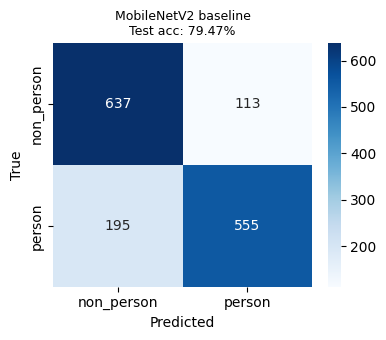

✅ Saved: mobilenetv2_baseline_cm.png


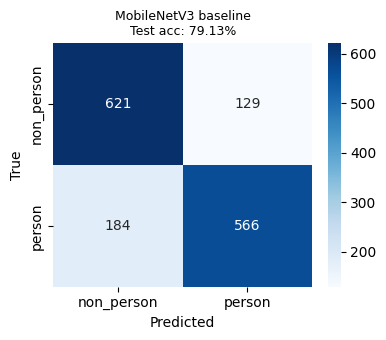

✅ Saved: mobilenetv3_baseline_cm.png


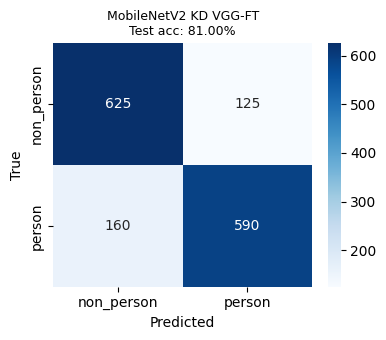

✅ Saved: mobilenetv2_kd_vgg_ft_cm.png


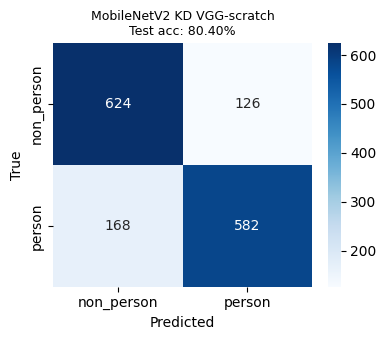

✅ Saved: mobilenetv2_kd_vgg_scratch_cm.png


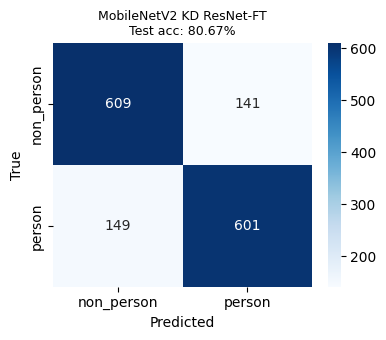

✅ Saved: mobilenetv2_kd_resnet_ft_cm.png


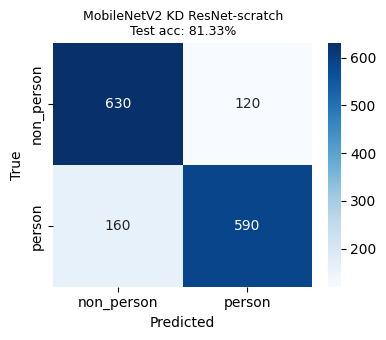

✅ Saved: mobilenetv2_kd_resnet_scratch_cm.png


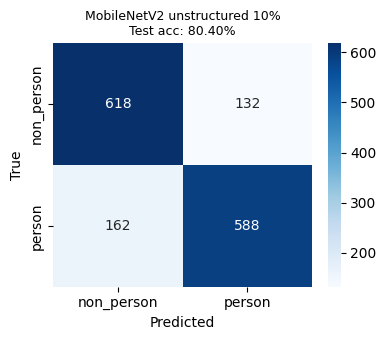

✅ Saved: mobilenetv2_unstructured_10pct_cm.png


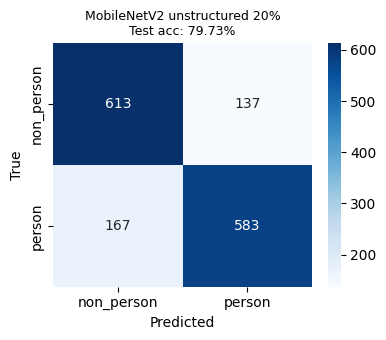

✅ Saved: mobilenetv2_unstructured_20pct_cm.png


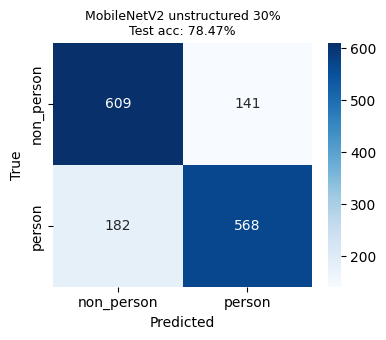

✅ Saved: mobilenetv2_unstructured_30pct_cm.png


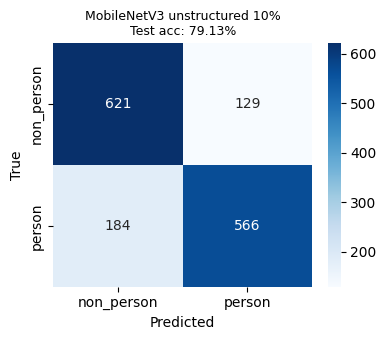

✅ Saved: mobilenetv3_unstructured_10pct_cm.png


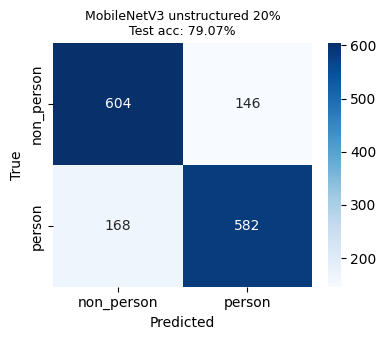

✅ Saved: mobilenetv3_unstructured_20pct_cm.png


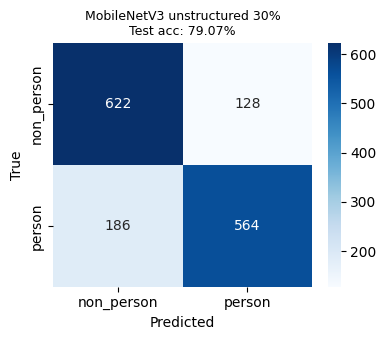

✅ Saved: mobilenetv3_unstructured_30pct_cm.png


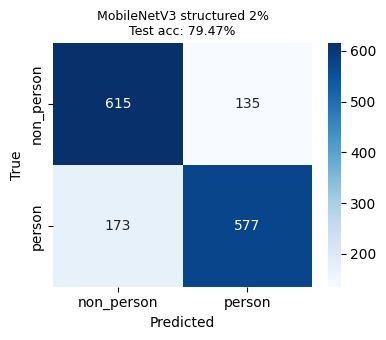

✅ Saved: mobilenetv3_structured_2pct_cm.png


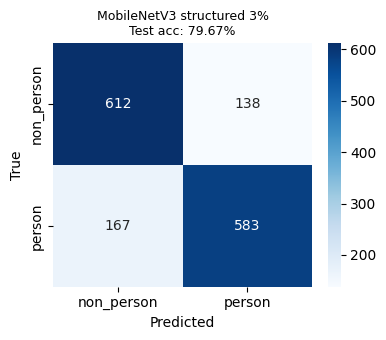

✅ Saved: mobilenetv3_structured_3pct_cm.png


In [9]:
# ── Confusion matrices — saved to Drive ─────────────────────────────
for name in key_models:
    if name not in results or results[name]["acc"] is None:
        continue
    r  = results[name]
    cm = confusion_matrix(r["labels"], r["preds"])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["non_person", "person"],
                yticklabels=["non_person", "person"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    acc_pct = results[name]["acc"] * 100
    ax.set_title(f"{name}\nTest acc: {acc_pct:.2f}%", fontsize=9)
    plt.tight_layout()
    fname = name.lower().replace(" ", "_").replace("%", "pct").replace("-", "_") + "_cm.png"
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {fname}")

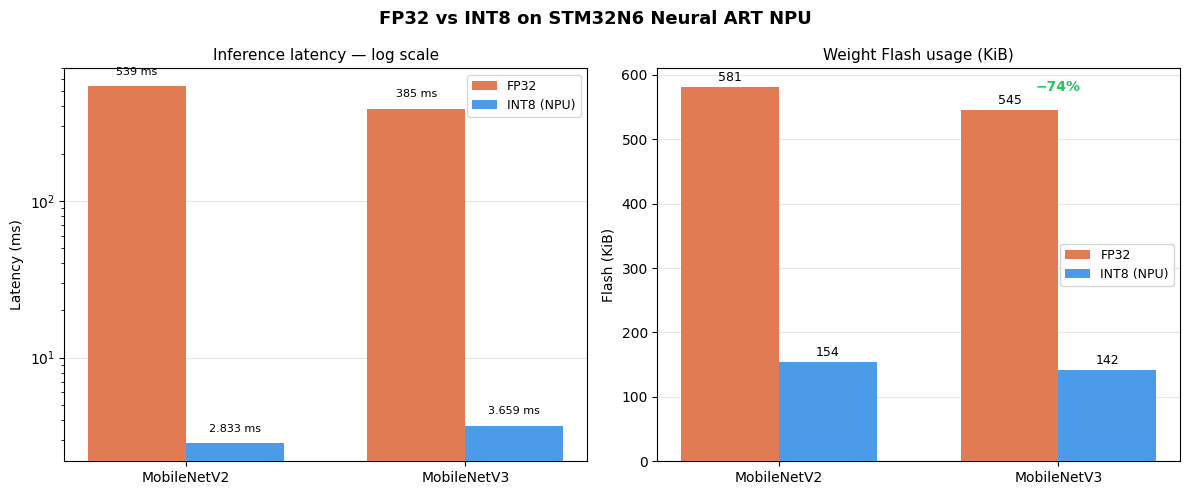

✅ Saved: hw_fp32_vs_int8.png


In [10]:
# ── Figure A: FP32 vs INT8 hardware comparison ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arch_labels = ["MobileNetV2", "MobileNetV3"]
fp32_ms     = [538.8,   385.4]
int8_ms     = [2.833,   3.659]
fp32_flash  = [580.9,   544.7]
int8_flash  = [154.5,   141.7]
speedups    = [190,     105]
mem_reduc   = [73,      74]

x = np.arange(len(arch_labels))
w = 0.35
c_fp32, c_int8 = "#e07b54", "#4c9be8"

# Panel 1: Latency (log scale)
ax = axes[0]
b1 = ax.bar(x - w/2, fp32_ms,  w, color=c_fp32, label="FP32", zorder=3)
b2 = ax.bar(x + w/2, int8_ms,  w, color=c_int8, label="INT8 (NPU)", zorder=3)
ax.set_yscale("log")
ax.set_title("Inference latency — log scale", fontsize=11)
ax.set_ylabel("Latency (ms)")
ax.set_xticks(x); ax.set_xticklabels(arch_labels)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3, zorder=0)
for bar, val in zip(b1, fp32_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.15,
            f"{val:.0f} ms", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b2, int8_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.15,
            f"{val:.3f} ms", ha="center", va="bottom", fontsize=8)
for i, sp in enumerate(speedups):
    ax.annotate(f"{sp}× faster", xy=(x[i], fp32_ms[i]*2),
                ha="center", fontsize=10, fontweight="bold", color="#22c55e")

# Panel 2: Flash memory
ax = axes[1]
b1 = ax.bar(x - w/2, fp32_flash, w, color=c_fp32, label="FP32", zorder=3)
b2 = ax.bar(x + w/2, int8_flash, w, color=c_int8, label="INT8 (NPU)", zorder=3)
ax.set_title("Weight Flash usage (KiB)", fontsize=11)
ax.set_ylabel("Flash (KiB)")
ax.set_xticks(x); ax.set_xticklabels(arch_labels)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3, zorder=0)
for bar, val in zip(b1, fp32_flash):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9)
for bar, val in zip(b2, int8_flash):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9)
for i, r in enumerate(mem_reduc):
    ax.annotate(f"−{r}%", xy=(x[i], fp32_flash[i] + 30),
                ha="center", fontsize=10, fontweight="bold", color="#22c55e")

fig.suptitle("FP32 vs INT8 on STM32N6 Neural ART NPU",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "hw_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: hw_fp32_vs_int8.png")

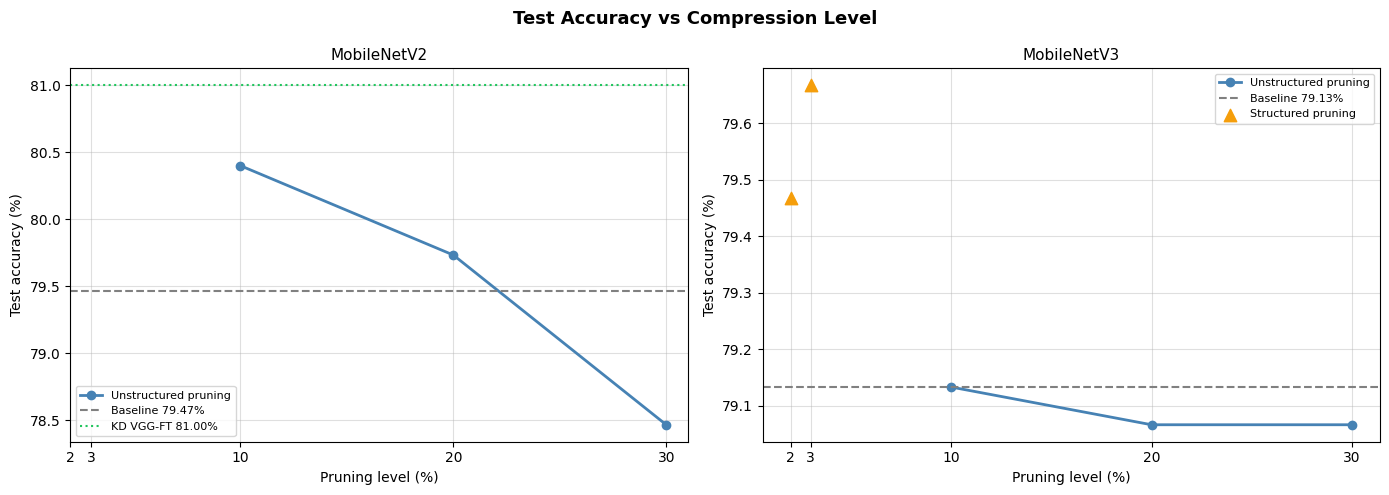

✅ Saved: final_accuracy_chart.png


In [11]:
# ── Figure B: Accuracy vs compression level ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Test Accuracy vs Compression Level",
             fontsize=13, fontweight="bold")

for ax, arch in zip(axes, ["MobileNetV2", "MobileNetV3"]):
    baseline_r   = results.get(f"{arch} baseline", {})
    baseline_acc = baseline_r["acc"] * 100 if baseline_r.get("acc") else None

    amounts, test_accs = [], []
    for pct in [10, 20, 30]:
        r = results.get(f"{arch} unstructured {pct}%", {})
        if r.get("acc"):
            amounts.append(pct)
            test_accs.append(r["acc"] * 100)

    if amounts:
        ax.plot(amounts, test_accs, "o-", color="steelblue",
                linewidth=2, markersize=6, label="Unstructured pruning")

    if baseline_acc:
        ax.axhline(baseline_acc, color="gray", linestyle="--",
                   linewidth=1.5, label=f"Baseline {baseline_acc:.2f}%")

    # KD best line — only for models that exist
    if arch == "MobileNetV2":
        kd_r = results.get("MobileNetV2 KD VGG-FT", {})
        if kd_r.get("acc"):
            ax.axhline(kd_r["acc"] * 100, color="#22c55e", linestyle=":",
                       linewidth=1.5, label=f"KD VGG-FT {kd_r['acc']*100:.2f}%")

    # Structured pruning points
    struct_accs = {}
    for pct_s, label_s in [("2%", "Structured 2%"), ("3%", "Structured 3%")]:
        r = results.get(f"{arch} structured {pct_s}", {})
        if r.get("acc"):
            struct_accs[int(pct_s[:-1])] = r["acc"] * 100
    if struct_accs:
        ax.scatter(list(struct_accs.keys()), list(struct_accs.values()),
                   marker="^", color="#f59e0b", s=80, zorder=5,
                   label="Structured pruning")

    ax.set_title(arch, fontsize=11)
    ax.set_xlabel("Pruning level (%)")
    ax.set_ylabel("Test accuracy (%)")
    ax.set_xticks([2, 3, 10, 20, 30])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_DIR / "final_accuracy_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: final_accuracy_chart.png")

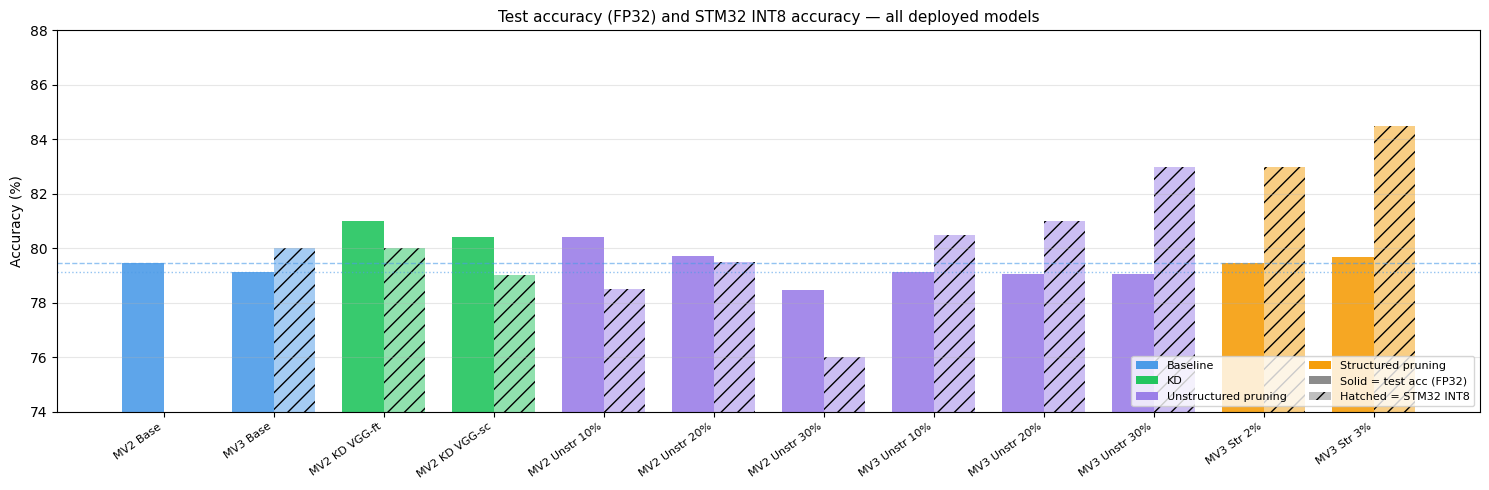

✅ Saved: all_models_accuracy.png


In [12]:
# ── Figure C: All-models accuracy bar chart ──────────────────────────
plot_cfg = [
    ("MobileNetV2 baseline",        "MV2 Base",      "baseline"),
    ("MobileNetV3 baseline",        "MV3 Base",      "baseline"),
    ("MobileNetV2 KD VGG-FT",      "MV2 KD VGG-ft", "kd"),
    ("MobileNetV2 KD VGG-scratch", "MV2 KD VGG-sc", "kd"),
    ("MobileNetV2 unstructured 10%","MV2 Unstr 10%", "pruning"),
    ("MobileNetV2 unstructured 20%","MV2 Unstr 20%", "pruning"),
    ("MobileNetV2 unstructured 30%","MV2 Unstr 30%", "pruning"),
    ("MobileNetV3 unstructured 10%","MV3 Unstr 10%", "pruning"),
    ("MobileNetV3 unstructured 20%","MV3 Unstr 20%", "pruning"),
    ("MobileNetV3 unstructured 30%","MV3 Unstr 30%", "pruning"),
    ("MobileNetV3 structured 2%",  "MV3 Str 2%",    "structured"),
    ("MobileNetV3 structured 3%",  "MV3 Str 3%",    "structured"),
]
cat_col = {"baseline": "#4c9be8", "kd": "#22c55e",
           "pruning": "#9b7fe8",  "structured": "#f59e0b"}

labels_plot, test_list, stm32_list, cols_list = [], [], [], []
for full_name, short, cat in plot_cfg:
    r = results.get(full_name, {})
    if not r.get("acc"):
        continue
    s32 = stm32.get(results[full_name]["stm32_key"], {}) if results[full_name]["stm32_key"] else {}
    labels_plot.append(short)
    test_list.append(r["acc"] * 100)
    stm32_list.append(s32.get("stm32_int8") or 0)
    cols_list.append(cat_col[cat])

x = np.arange(len(labels_plot))
w = 0.38

fig, ax = plt.subplots(figsize=(15, 5))
b1 = ax.bar(x - w/2, test_list,  w, color=cols_list, alpha=0.90,
            label="Test acc — FP32 (1,500 samples)")
b2 = ax.bar(x + w/2, stm32_list, w, color=cols_list, alpha=0.50,
            hatch="//", label="STM32 INT8 acc (200 samples)")

# Baseline reference lines
ax.axhline(79.47, color="#4c9be8", linestyle="--",
           linewidth=1, alpha=0.6, label="MV2 baseline test (79.47%)")
ax.axhline(79.13, color="#4c9be8", linestyle=":",
           linewidth=1, alpha=0.6, label="MV3 baseline test (79.13%)")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Test accuracy (FP32) and STM32 INT8 accuracy — all deployed models",
             fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=35, ha="right", fontsize=8)
ax.set_ylim(74, 88)
ax.grid(True, axis="y", alpha=0.3)

# Legend: technique colours + bar types
legend_els = [
    mpatches.Patch(facecolor=cat_col["baseline"], label="Baseline"),
    mpatches.Patch(facecolor=cat_col["kd"],       label="KD"),
    mpatches.Patch(facecolor=cat_col["pruning"],  label="Unstructured pruning"),
    mpatches.Patch(facecolor=cat_col["structured"],label="Structured pruning"),
    mpatches.Patch(facecolor="gray", alpha=0.9,   label="Solid = test acc (FP32)"),
    mpatches.Patch(facecolor="gray", alpha=0.5, hatch="//", label="Hatched = STM32 INT8"),
]
ax.legend(handles=legend_els, fontsize=8, loc="lower right", ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "all_models_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: all_models_accuracy.png")

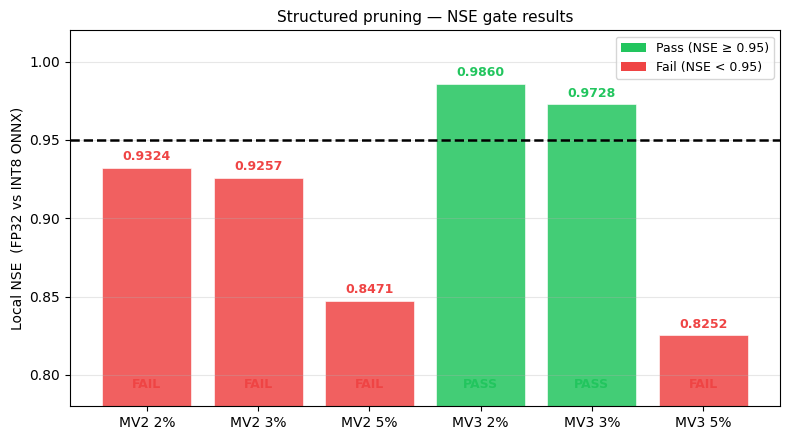

✅ Saved: structured_pruning_nse_gate.png


In [13]:
# ── Figure D: Structured pruning NSE gate ────────────────────────────
struct_data = [
    ("MV2 2%",  0.9324, False),
    ("MV2 3%",  0.9257, False),
    ("MV2 5%",  0.8471, False),
    ("MV3 2%",  0.9860, True),
    ("MV3 3%",  0.9728, True),
    ("MV3 5%",  0.8252, False),
]

names_s = [d[0] for d in struct_data]
nse_s   = [d[1] for d in struct_data]
passed  = [d[2] for d in struct_data]
bar_cols = ["#22c55e" if p else "#ef4444" for p in passed]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names_s, nse_s, color=bar_cols, alpha=0.85,
              edgecolor="white", linewidth=0.5)
ax.axhline(0.95, color="black", linestyle="--",
           linewidth=1.8, label="NSE gate threshold = 0.95")
ax.set_ylim(0.78, 1.02)
ax.set_ylabel("Local NSE  (FP32 vs INT8 ONNX)", fontsize=10)
ax.set_title("Structured pruning — NSE gate results", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)

for bar, val, p in zip(bars, nse_s, passed):
    col = "#22c55e" if p else "#ef4444"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=9, color=col, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 0.79,
            "PASS" if p else "FAIL", ha="center", va="bottom",
            fontsize=9, color=col, fontweight="bold")

# Colour legend
legend_els = [
    mpatches.Patch(facecolor="#22c55e", label="Pass (NSE ≥ 0.95)"),
    mpatches.Patch(facecolor="#ef4444", label="Fail (NSE < 0.95)"),
]
ax.legend(handles=legend_els + ax.get_legend_handles_labels()[0][2:],
          fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "structured_pruning_nse_gate.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("✅ Saved: structured_pruning_nse_gate.png")

In [14]:
# ── Save results to JSON ─────────────────────────────────────────────
summary = {}
for name, r in results.items():
    if r["acc"] is None:
        continue
    s32 = stm32.get(r["stm32_key"], {}) if r["stm32_key"] else {}
    summary[name] = {
        "val_acc_%"    : VAL_ACCS.get(name),
        "test_acc_%"   : round(r["acc"] * 100, 2),
        "stm32_fp32_%" : s32.get("stm32_fp32"),
        "stm32_int8_%" : s32.get("stm32_int8"),
        "NSE"          : s32.get("nse"),
    }

out_path = Path("/content/drive/My Drive/stm32-thesis/outputs/final_test_results.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(summary, indent=2))
print(f"✅ Saved to: {out_path}")
print(json.dumps(summary, indent=2))

✅ Saved to: /content/drive/My Drive/stm32-thesis/outputs/final_test_results.json
{
  "MobileNetV2 baseline": {
    "val_acc_%": 78.4,
    "test_acc_%": 79.47,
    "stm32_fp32_%": 76.5,
    "stm32_int8_%": null,
    "NSE": 0.9777
  },
  "MobileNetV3 baseline": {
    "val_acc_%": 79.13,
    "test_acc_%": 79.13,
    "stm32_fp32_%": 79.5,
    "stm32_int8_%": 80.0,
    "NSE": 0.9931
  },
  "VGG Pretrained (teacher)": {
    "val_acc_%": 89.07,
    "test_acc_%": 90.6,
    "stm32_fp32_%": null,
    "stm32_int8_%": null,
    "NSE": null
  },
  "ResNet Pretrained (teacher)": {
    "val_acc_%": 87.93,
    "test_acc_%": 89.73,
    "stm32_fp32_%": null,
    "stm32_int8_%": null,
    "NSE": null
  },
  "MobileNetV2 KD VGG-FT": {
    "val_acc_%": 80.07,
    "test_acc_%": 81.0,
    "stm32_fp32_%": null,
    "stm32_int8_%": 80.0,
    "NSE": 0.987
  },
  "MobileNetV2 KD VGG-scratch": {
    "val_acc_%": 79.53,
    "test_acc_%": 80.4,
    "stm32_fp32_%": null,
    "stm32_int8_%": 79.0,
    "NSE": 0.9827
 